In [1]:
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt 
from sklearn.model_selection import train_test_split

In [2]:
df = sns.load_dataset("titanic")

In [3]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [4]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [5]:
df.shape

(891, 15)

In [6]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [8]:
from sklearn.impute import SimpleImputer

In [9]:
im = SimpleImputer(strategy = "median")
df[["age"]] = im.fit_transform(df[["age"]])

im = SimpleImputer(strategy = "most_frequent")
df[["embarked"]] = im.fit_transform(df[["embarked"]])

In [10]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age              0
sibsp            0
parch            0
fare             0
embarked         0
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [11]:
from sklearn.preprocessing import LabelEncoder

In [12]:
le = LabelEncoder()

In [13]:
df["sex"] = le.fit_transform(df["sex"])
df["embarked"] = le.fit_transform(df["embarked"])

In [14]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,1,22.0,1,0,7.2500,2,Third,man,True,NaN,Southampton,no,False
1,1,1,0,38.0,1,0,71.2833,0,First,woman,False,C,Cherbourg,yes,False
2,1,3,0,26.0,0,0,7.9250,2,Third,woman,False,NaN,Southampton,yes,True
3,1,1,0,35.0,1,0,53.1000,2,First,woman,False,C,Southampton,yes,False
4,0,3,1,35.0,0,0,8.0500,2,Third,man,True,NaN,Southampton,no,True


In [15]:
features = ["sex","age","fare","embarked","pclass"]
target = ["survived"]

In [16]:
x = df[features]
y = df[target]

In [17]:
x.head()

,sex,age,fare,embarked,pclass
0,1,22.0,7.2500,2,3
1,0,38.0,71.2833,0,1
2,0,26.0,7.9250,2,3
3,0,35.0,53.1000,2,1
4,1,35.0,8.0500,2,3


In [18]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2,random_state = 42)

In [19]:
from sklearn.tree import DecisionTreeClassifier

In [20]:
model = DecisionTreeClassifier()

In [21]:
model.fit(x_train,y_train)

DecisionTreeClassifier()

In [22]:
y_pred = model.predict(x_test)

In [23]:
from sklearn.metrics import accuracy_score,precision_score

In [24]:
accuracy_score(y_test,y_pred)

0.7653631284916201

In [25]:
from sklearn.tree import plot_tree

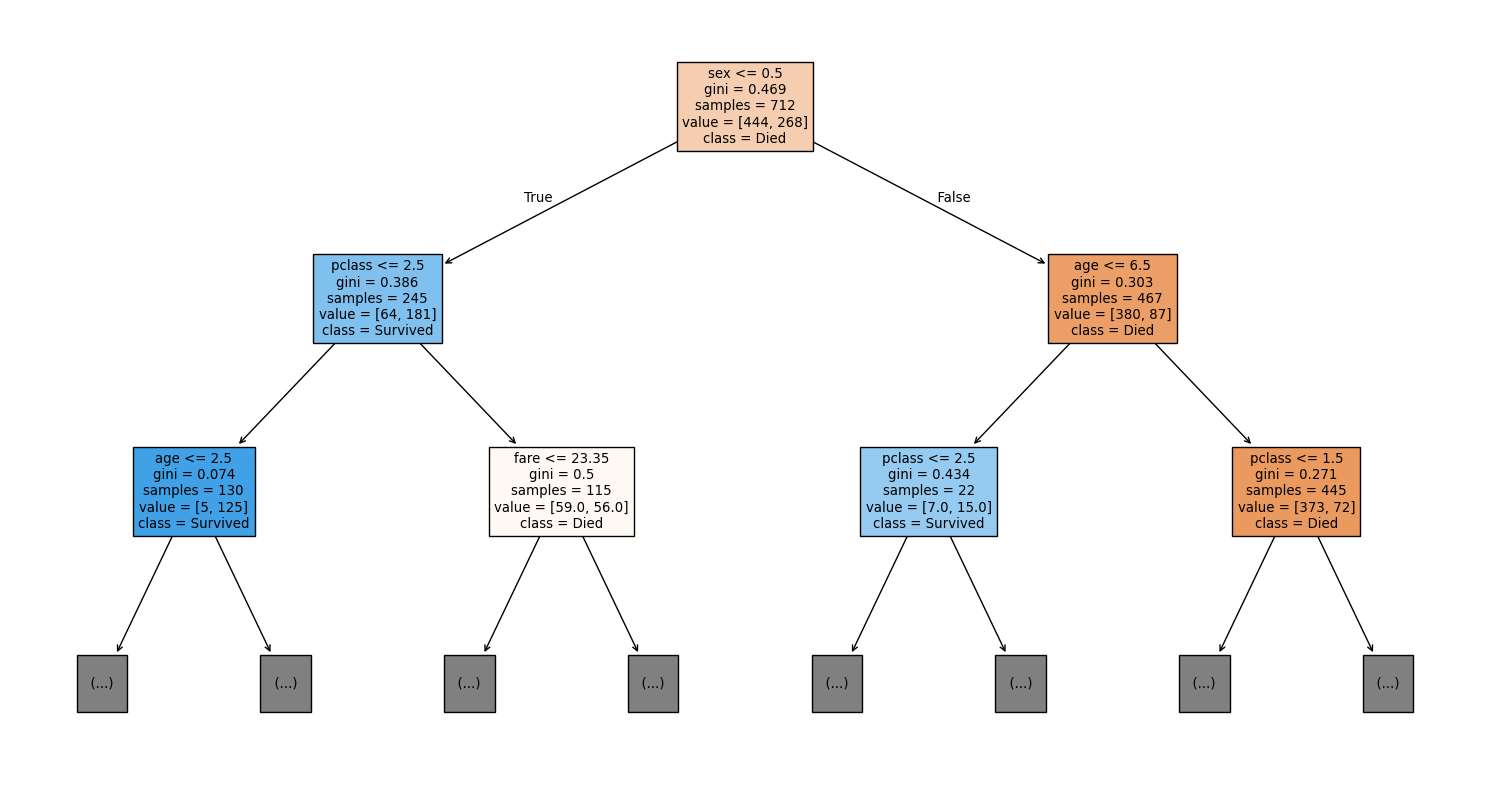

In [26]:
plt.figure(figsize = (15,8))
plot_tree(model,feature_names = x.columns,class_names = ["Died","Survived"],filled = True,max_depth = 2)
plt.tight_layout()
plt.show()

In [27]:
max_depth = [2,3,4,5,6,7,8,9]

for depth in max_depth:
    model.fit(x_train,y_train)
    acc = model.score(x_test,y_test)
    print(f"accuracy: {acc} for max_dpth:{depth}")
    

accuracy: 0.776536312849162 for max_dpth:2
accuracy: 0.7653631284916201 for max_dpth:3
accuracy: 0.770949720670391 for max_dpth:4
accuracy: 0.7653631284916201 for max_dpth:5
accuracy: 0.7653631284916201 for max_dpth:6
accuracy: 0.7653631284916201 for max_dpth:7
accuracy: 0.770949720670391 for max_dpth:8
accuracy: 0.770949720670391 for max_dpth:9


# post purning

In [28]:
full_tree = DecisionTreeClassifier(random_state = 42)

In [29]:
full_tree.fit(x_train,y_train)

DecisionTreeClassifier(random_state=42)

In [30]:
path = full_tree.cost_complexity_pruning_path(x_train,y_train)
ccp_alpha = path.ccp_alphas

In [31]:
ccp_alpha

array([0.00000000e+00, 0.00000000e+00, 6.68806849e-05, 1.45921494e-04,
       1.84428555e-04, 2.00642055e-04, 2.34082397e-04, 2.34082397e-04,
       2.34082397e-04, 3.51123596e-04, 4.68164794e-04, 4.68164794e-04,
       5.61797753e-04, 6.24219725e-04, 6.67991230e-04, 7.02247191e-04,
       7.02247191e-04, 8.19288390e-04, 8.19288390e-04, 8.32292967e-04,
       8.42696629e-04, 8.42696629e-04, 8.94231048e-04, 8.99610781e-04,
       9.24769963e-04, 9.36329588e-04, 9.36329588e-04, 9.36329588e-04,
       9.88347898e-04, 1.00253471e-03, 1.02996255e-03, 1.05337079e-03,
       1.07400895e-03, 1.08038029e-03, 1.11865144e-03, 1.12359551e-03,
       1.12359551e-03, 1.13139825e-03, 1.18841832e-03, 1.22566125e-03,
       1.22893258e-03, 1.22893258e-03, 1.24361593e-03, 1.24843945e-03,
       1.27565833e-03, 1.30996111e-03, 1.33761370e-03, 1.37044603e-03,
       1.47927070e-03, 1.51142557e-03, 1.54072312e-03, 1.56675436e-03,
       1.60434338e-03, 1.66892062e-03, 1.75561798e-03, 1.76144762e-03,
      

In [32]:
#  train model for all alphas
tree = []

for alpha in ccp_alpha:
    model = DecisionTreeClassifier(random_state = 42,ccp_alpha = alpha)
    model.fit(x_train,y_train)
    tree.append((model,alpha))

In [33]:
best_acc = 0
best_alpha = 0

for model,alpha in tree:
    curr_acc = model.score(x_test,y_test)
    if curr_acc > best_acc:
        best_acc = curr_acc
        best_alpha = alpha

In [34]:
best_alpha

np.float64(0.0015407231242023183)

In [35]:
best_model = DecisionTreeClassifier(ccp_alpha = best_alpha)
best_model.fit(x_train,y_train)

DecisionTreeClassifier(ccp_alpha=np.float64(0.0015407231242023183))

In [36]:
best_model

DecisionTreeClassifier(ccp_alpha=np.float64(0.0015407231242023183))

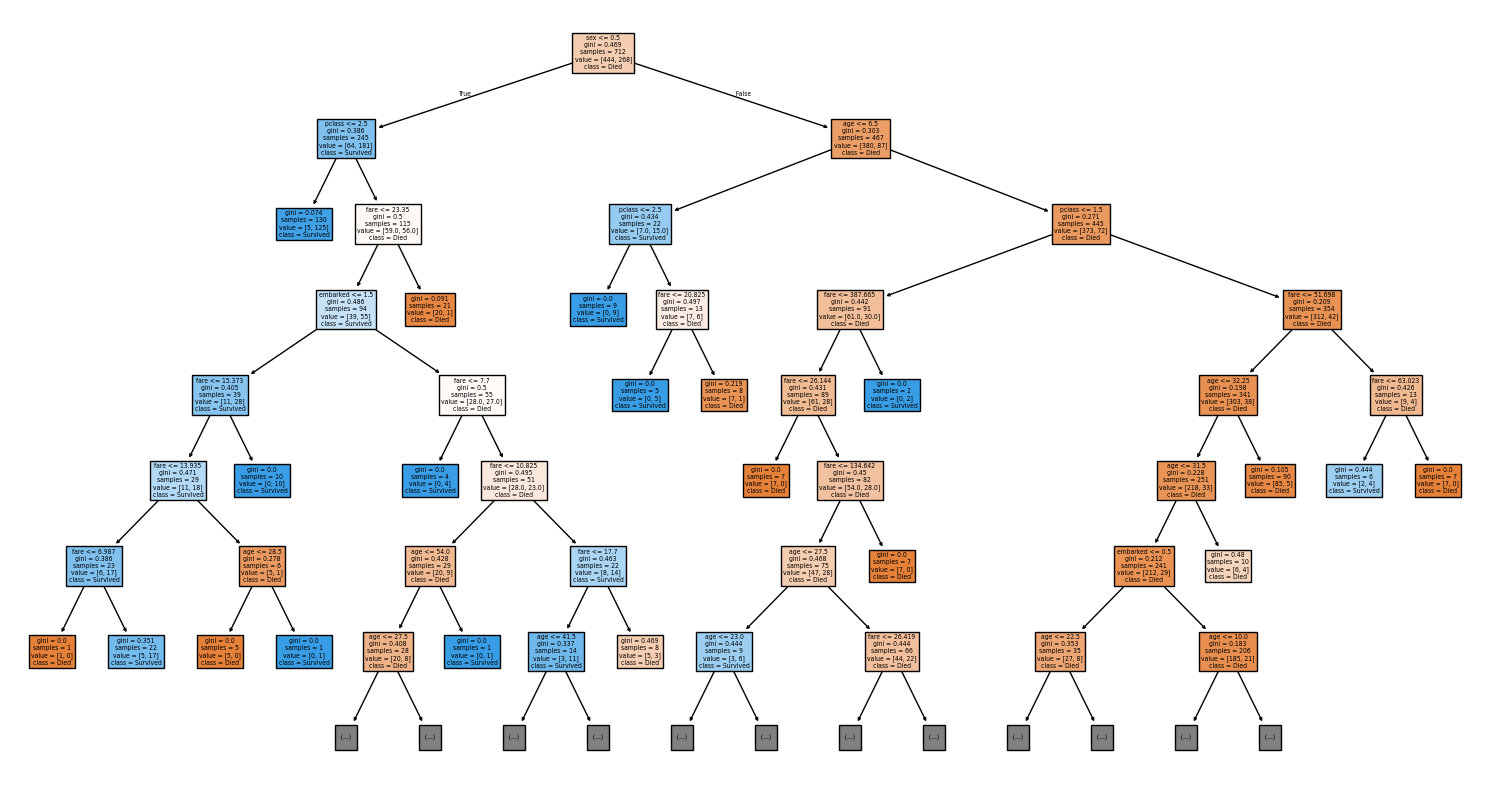

In [37]:
plt.figure(figsize = (15,8))
plot_tree(best_model,feature_names = x.columns,class_names = ["Died","Survived"],filled = True,max_depth = 7)
plt.tight_layout()
plt.show()

In [38]:
best_acc

0.8324022346368715